In [ ]:
import pandas as pd

df = pd.read_csv('D:/Summer_2/Projects/support-ticket-agent/data/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv')
en = df[df['language'] == 'en'].copy()
en = en.drop(columns=['tag_5', 'tag_6', 'tag_7', 'tag_8'])

print(en.shape)
en.head()

In [2]:
import matplotlib.pyplot as plt

en['body_length'] = en['body'].apply(len)

en.groupby('priority')['body_length'].describe()

,count,mean,std,min,25%,50%,75%,max
priority,,,,,,,,
high,6346.0,369.462023,177.561575,6.0,220.0,381.5,530.0,1147.0
low,3374.0,366.257854,182.562374,15.0,203.0,374.5,536.0,1049.0
medium,6618.0,367.208220,180.738882,15.0,214.0,375.0,534.0,1114.0


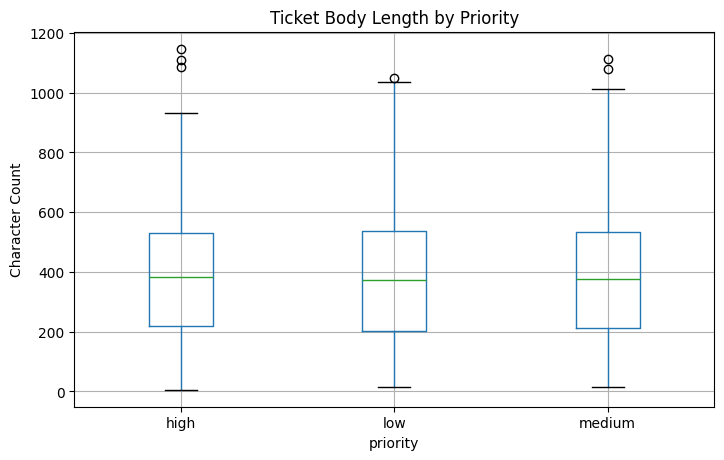

In [3]:
en.boxplot(column='body_length', by='priority', figsize=(8,5))
plt.title('Ticket Body Length by Priority')
plt.suptitle('')
plt.ylabel('Character Count')
plt.show()

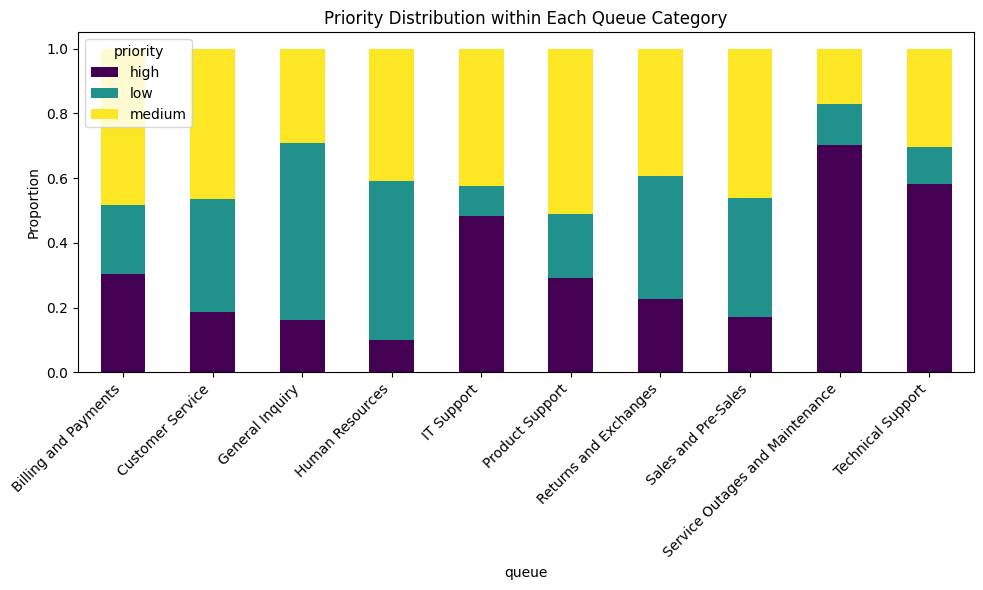

In [4]:
import seaborn as sns

pd.crosstab(en['queue'], en['priority'], normalize='index').plot(
    kind='bar', stacked=True, figsize=(10,6), colormap='viridis'
)
plt.title('Priority Distribution within Each Queue Category')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
from collections import Counter
import re

def get_top_words(text_series, n=15):
    words = ' '.join(text_series).lower()
    words = re.findall(r'\b[a-z]{3,}\b', words)  # words with 3+ letters
    stopwords = {'the','and','for','are','was','has','have','with','this','that','been','from','not','you','your'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

for p in en['priority'].unique():
    print(f"\n=== Top words for priority: {p} ===")
    print(get_top_words(en[en['priority'] == p]['body']))


=== Top words for priority: high ===
[('data', 3972), ('our', 3172), ('issue', 3079), ('would', 3006), ('support', 2604), ('could', 2419), ('assistance', 2222), ('software', 2187), ('customer', 2095), ('appreciate', 1955), ('provide', 1930), ('due', 1872), ('security', 1799), ('information', 1776), ('system', 1747)]

=== Top words for priority: medium ===
[('data', 4314), ('would', 3451), ('our', 3205), ('issue', 2852), ('support', 2812), ('could', 2798), ('customer', 2367), ('assistance', 2264), ('provide', 2194), ('information', 2154), ('appreciate', 2148), ('software', 2124), ('due', 1847), ('security', 1778), ('please', 1747)]

=== Top words for priority: low ===
[('data', 2105), ('would', 1830), ('could', 1552), ('support', 1475), ('issue', 1452), ('our', 1378), ('customer', 1264), ('provide', 1214), ('information', 1205), ('assistance', 1166), ('appreciate', 1121), ('software', 1042), ('please', 985), ('due', 963), ('any', 957)]
